In [1]:
import numpy as np
import pandas as pd
import glob
import os
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNetCV

# See if all files have same CpG probes

In [2]:
input_dir = "TCGA_normal_beta_files/gdc_download_20260606_164603.003427"

files = glob.glob(
    os.path.join(input_dir, "**/*methylation_array.sesame.level3betas.txt"),
    recursive=True
)

print(f"Found {len(files)} files")

dfs = []
for f in files[:10]:
    df = pd.read_csv(f, sep="\t", header=None)
    print(os.path.basename(f), df.shape)

Found 75 files
9102ccb5-f20c-4f5b-9fc0-6973c3f0381f.methylation_array.sesame.level3betas.txt (486427, 2)
5c28a678-39ba-4a1f-91bb-6064457c5b5d.methylation_array.sesame.level3betas.txt (486427, 2)
f8c592a9-aec8-468d-9df0-4db40c9cc311.methylation_array.sesame.level3betas.txt (486427, 2)
af0f4de3-3835-4296-84ae-6273f2a9e4cd.methylation_array.sesame.level3betas.txt (486427, 2)
1cb177b5-4a9b-41d5-aae3-8d806eaf6b7b.methylation_array.sesame.level3betas.txt (486427, 2)
54e7953a-11a9-4bfe-802a-36c425f69c97.methylation_array.sesame.level3betas.txt (486427, 2)
ad1210ef-7129-4e3a-8c17-8c14e0381920.methylation_array.sesame.level3betas.txt (486427, 2)
8e05fcfb-c01e-4496-8eaa-ed27c24c92b7.methylation_array.sesame.level3betas.txt (486427, 2)
49b13df5-de30-4678-9afe-99f000a78636.methylation_array.sesame.level3betas.txt (486427, 2)
eb34920a-abd0-4211-9893-378b32ff9716.methylation_array.sesame.level3betas.txt (486427, 2)


# Append all the sample data

In [3]:
# input_dir = "TCGA_normal_beta_files/gdc_download_20260606_164603.003427"

# files = glob.glob(
#     os.path.join(
#         input_dir,
#         "**/*methylation_array.sesame.level3betas.txt"
#     ),
#     recursive=True
# )

# print("Found", len(files), "files")

# # Read first file
# first = pd.read_csv(
#     files[0],
#     sep="\t",
#     header=None,
#     names=["CpG", "beta"]
# )

# merged_df = pd.DataFrame()
# merged_df["CpG"] = first["CpG"]

# for i, f in enumerate(files):

#     sample_name = os.path.basename(f)

#     df = pd.read_csv(
#         f,
#         sep="\t",
#         header=None,
#         names=["CpG", sample_name],
#         dtype={sample_name: "float32"}
#     )

#     merged_df[sample_name] = df[sample_name]

#     if i % 10 == 0:
#         print(i, "samples processed")

# print(merged_df.shape)

In [4]:
sample_sheet_normal = pd.read_csv("Normal_metadata/gdc_sample_sheet.2026-06-07.tsv", sep = '\t')
sample_sheet_normal.head(3)

,File ID,File Name,Data Category,Data Type,Project ID,Case ID,Sample ID,Tissue Type,Tumor Descriptor,Specimen Type,Preservation Method
0,af5c7ee8-6981-4daf-b5a2-589c0a2bad9a,e5e37029-fb06-4e34-b3b2-277854b8f59a.methylati...,DNA Methylation,Methylation Beta Value,TCGA-BRCA,TCGA-BH-A1F5,TCGA-BH-A1F5-11A,Normal,Not Applicable,Solid Tissue,OCT
1,2ad10fdc-8240-4a4c-825a-f48655f8e9ee,d65249d9-4d0c-4a47-aee2-6d7c59b6ef8b.methylati...,DNA Methylation,Methylation Beta Value,TCGA-BRCA,TCGA-BH-A1FB,TCGA-BH-A1FB-11A,Normal,Not Applicable,Solid Tissue,OCT
2,520d94db-21b5-4084-99db-1b693cc9c331,79512f6f-1092-46d8-863c-5a9d052549b1.methylati...,DNA Methylation,Methylation Beta Value,TCGA-BRCA,TCGA-E9-A1NF,TCGA-E9-A1NF-11A,Normal,Not Applicable,Solid Tissue,OCT


In [5]:
sample_sheet_normal.columns

Index(['File ID', 'File Name', 'Data Category', 'Data Type', 'Project ID',
       'Case ID', 'Sample ID', 'Tissue Type', 'Tumor Descriptor',
       'Specimen Type', 'Preservation Method'],
      dtype='object')

In [6]:
sample_sheet_normal["Preservation Method"].value_counts()

Preservation Method
OCT        40
Unknown    35
Name: count, dtype: int64

# Changing column names from file name to sample ids for easier and cleaner analysis

In [7]:
# ----------------------------
# Read sample sheet
# ----------------------------
sample_sheet_normal = pd.read_csv(
    "Normal_metadata/gdc_sample_sheet.2026-06-07.tsv",
    sep="\t"
)

# Create filename -> Sample ID mapping
file_to_sample = dict(
    zip(sample_sheet_normal["File Name"],
        sample_sheet_normal["Sample ID"])
)

input_dir = "TCGA_normal_beta_files/gdc_download_20260606_164603.003427"

files = glob.glob(
    os.path.join(
        input_dir,
        "**/*methylation_array.sesame.level3betas.txt"
    ),
    recursive=True
)

# Read first file
first = pd.read_csv(
    files[0],
    sep="\t",
    header=None,
    names=["CpG", "beta"]
)

beta_normal = pd.DataFrame()
beta_normal["CpG"] = first["CpG"]

#print(beta)

for f in files:

    filename = os.path.basename(f)

    sample_id = file_to_sample[filename]

    df = pd.read_csv(
        f,
        sep="\t",
        header=None,
        names=["CpG", sample_id],
        dtype={sample_id: "float32"}
    )

    beta_normal[sample_id] = df[sample_id]

print(beta_normal.shape)

(486427, 76)


In [8]:
beta_normal.head()

,CpG,TCGA-BH-A0B8-11A,TCGA-BH-A0C3-11A,TCGA-A7-A13E-11A,TCGA-BH-A1EU-11A,TCGA-BH-A0E0-11A,TCGA-E9-A1RC-11A,TCGA-BH-A1ES-11A,TCGA-E9-A1N5-11A,TCGA-E2-A1LS-11A,...,TCGA-BH-A1FB-11A,TCGA-AC-A23H-11A,TCGA-BH-A0E1-11A,TCGA-AC-A2FG-11A,TCGA-E9-A1RD-11A,TCGA-BH-A0BJ-11A,TCGA-E9-A1RH-11A,TCGA-AC-A2FB-11A,TCGA-BH-A0BC-11A,TCGA-BH-A0BA-11A
0,cg00000029,0.218061,NaN,0.159645,0.135824,NaN,NaN,0.117070,0.088296,NaN,...,0.123376,NaN,0.128691,0.109361,0.161140,0.170829,0.155179,0.172706,0.133332,0.180909
1,cg00000108,0.964303,0.949930,0.957298,0.957291,0.964428,0.939351,0.959954,0.975026,0.918901,...,0.964434,0.966615,0.966429,0.972401,0.949433,0.962720,0.957195,0.974315,0.953457,0.961967
2,cg00000109,0.894325,0.876532,0.898092,0.907282,0.835853,0.843648,0.876166,0.878856,0.769147,...,0.836316,0.879010,0.858574,0.897998,0.890293,0.883313,0.908865,0.892226,0.921488,0.899080
3,cg00000165,0.205817,NaN,0.277576,0.276941,NaN,0.221119,NaN,0.215204,0.191632,...,0.245230,0.229452,0.216088,0.319390,0.141897,0.214752,0.189445,0.257707,0.270577,0.274910
4,cg00000236,0.905605,0.913460,0.862754,0.913258,0.913572,0.873757,0.918586,0.934173,0.897211,...,0.904866,0.896580,0.919016,0.904654,0.874599,0.921670,0.899076,0.893053,0.931892,0.890865


In [9]:
beta_normal.to_csv(
    "results/plots/BRCA_normal_beta_matrix.csv",
    index=False
)

## Missing Values

In [10]:
beta_normal.isna().sum().sum()

np.int64(5858964)

# Remove CpGs with missing values:

In [11]:
beta_normal = beta_normal.dropna()
print(beta_normal.shape)

(367665, 76)


# Beta Value Distribution

## Hist plot

In [12]:
# removing the cpg ids(1:) and removing column names (values-remove metadata), flatening the beta values in 1 dimention

values = beta_normal.iloc[:,1:].values.flatten()
values

array([0.96430314, 0.9499303 , 0.9572981 , ..., 0.95267195, 0.961024  ,
       0.95194316], shape=(27574875,), dtype=float32)

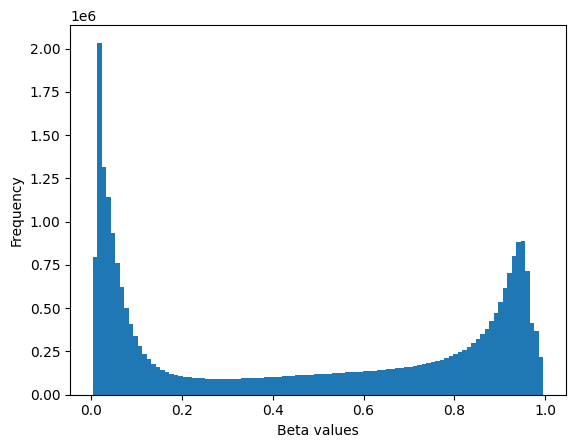

In [13]:
plt.hist(values, bins=100)
plt.xlabel("Beta values")
plt.ylabel("Frequency")
plt.savefig("results/plots/beta_distribution_plot.png")
plt.show()

## Density plot - Normal samples

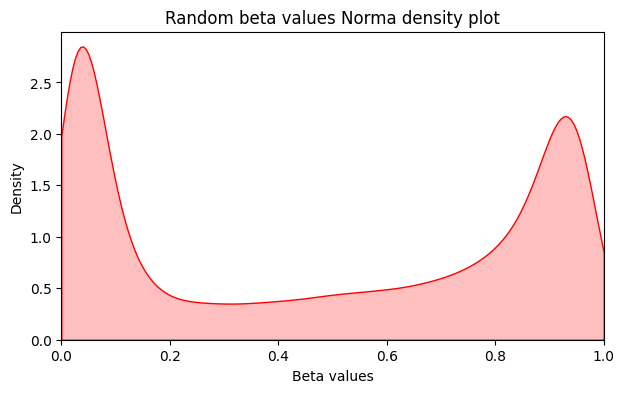

In [14]:
random_beta_normal = np.random.choice(beta_normal.iloc[:, 1:].values.flatten(), size=100000, replace=False)

plt.figure(figsize= (7,4))
sns.kdeplot(random_beta_normal, fill = True, color="red", clip=(0.0, 1.0))
plt.title("Random beta values Norma density plot")
plt.xlabel("Beta values")
plt.ylabel("Density")
plt.xlim(0,1)
plt.savefig("results/plots/Random beta values density plot")
plt.show()

# Calculate Most Variable CpGs

In [15]:
# It tells you how much a particular CpG locus varies from patient to patient in healthy breast tissue.

In [16]:
beta_normal["variance"] = beta_normal.iloc[:,1:].var(axis = 1)
beta_normal['variance'].shape

(367665,)

In [17]:
top_var = beta_normal.sort_values(
    "variance", ascending = False
)
top_var.head()

,CpG,TCGA-BH-A0B8-11A,TCGA-BH-A0C3-11A,TCGA-A7-A13E-11A,TCGA-BH-A1EU-11A,TCGA-BH-A0E0-11A,TCGA-E9-A1RC-11A,TCGA-BH-A1ES-11A,TCGA-E9-A1N5-11A,TCGA-E2-A1LS-11A,...,TCGA-AC-A23H-11A,TCGA-BH-A0E1-11A,TCGA-AC-A2FG-11A,TCGA-E9-A1RD-11A,TCGA-BH-A0BJ-11A,TCGA-E9-A1RH-11A,TCGA-AC-A2FB-11A,TCGA-BH-A0BC-11A,TCGA-BH-A0BA-11A,variance
171075,cg08866780,0.032639,0.966023,0.039107,0.981587,0.028850,0.935391,0.980427,0.030780,0.916079,...,0.909315,0.028330,0.975099,0.947242,0.026301,0.973003,0.983626,0.033475,0.034884,0.216985
399387,cg22621695,0.978969,0.912286,0.982386,0.972450,0.976763,0.053172,0.973977,0.062410,0.046697,...,0.051085,0.979021,0.081706,0.063518,0.971667,0.073091,0.065616,0.976190,0.983623,0.214596
406667,cg23057992,0.030306,0.086619,0.031765,0.034995,0.033606,0.949578,0.038799,0.961099,0.948673,...,0.945689,0.030252,0.961803,0.956553,0.029722,0.961928,0.964571,0.031606,0.035163,0.213585
235422,cg12662576,0.107326,0.127518,0.077556,0.957214,0.961961,0.931656,0.946602,0.032343,0.921185,...,0.916682,0.078639,0.051657,0.047772,0.956923,0.070488,0.070069,0.068705,0.956454,0.196076
457359,cg26214747,0.954769,0.093614,0.918014,0.956581,0.059308,0.897746,0.965398,0.045618,0.912898,...,0.918919,0.071441,0.950984,0.935598,0.069317,0.947483,0.955164,0.951769,0.062629,0.193139


In [18]:
top_var.to_csv(
    "results/tables/Top_variable_CpGs.csv",
    index=False
)

## Plotting top 1000 most variable probes

In [19]:
top_var_1k = top_var.head(100)
cpg_ids = top_var_1k.iloc[:, 0] #1st column
beta_val_1k = top_var_1k.iloc[:, 1:-1] #skipping 1st and als columns
print(cpg_ids.head())

171075    cg08866780
399387    cg22621695
406667    cg23057992
235422    cg12662576
457359    cg26214747
Name: CpG, dtype: object


In [20]:
beta_val_1k.head()

,TCGA-BH-A0B8-11A,TCGA-BH-A0C3-11A,TCGA-A7-A13E-11A,TCGA-BH-A1EU-11A,TCGA-BH-A0E0-11A,TCGA-E9-A1RC-11A,TCGA-BH-A1ES-11A,TCGA-E9-A1N5-11A,TCGA-E2-A1LS-11A,TCGA-BH-A1EY-11B,...,TCGA-BH-A1FB-11A,TCGA-AC-A23H-11A,TCGA-BH-A0E1-11A,TCGA-AC-A2FG-11A,TCGA-E9-A1RD-11A,TCGA-BH-A0BJ-11A,TCGA-E9-A1RH-11A,TCGA-AC-A2FB-11A,TCGA-BH-A0BC-11A,TCGA-BH-A0BA-11A
171075,0.032639,0.966023,0.039107,0.981587,0.028850,0.935391,0.980427,0.030780,0.916079,0.968159,...,0.020538,0.909315,0.028330,0.975099,0.947242,0.026301,0.973003,0.983626,0.033475,0.034884
399387,0.978969,0.912286,0.982386,0.972450,0.976763,0.053172,0.973977,0.062410,0.046697,0.045637,...,0.039664,0.051085,0.979021,0.081706,0.063518,0.971667,0.073091,0.065616,0.976190,0.983623
406667,0.030306,0.086619,0.031765,0.034995,0.033606,0.949578,0.038799,0.961099,0.948673,0.025829,...,0.969425,0.945689,0.030252,0.961803,0.956553,0.029722,0.961928,0.964571,0.031606,0.035163
235422,0.107326,0.127518,0.077556,0.957214,0.961961,0.931656,0.946602,0.032343,0.921185,0.951525,...,0.047260,0.916682,0.078639,0.051657,0.047772,0.956923,0.070488,0.070069,0.068705,0.956454
457359,0.954769,0.093614,0.918014,0.956581,0.059308,0.897746,0.965398,0.045618,0.912898,0.952678,...,0.057503,0.918919,0.071441,0.950984,0.935598,0.069317,0.947483,0.955164,0.951769,0.062629


## Plot a clustered heatmap

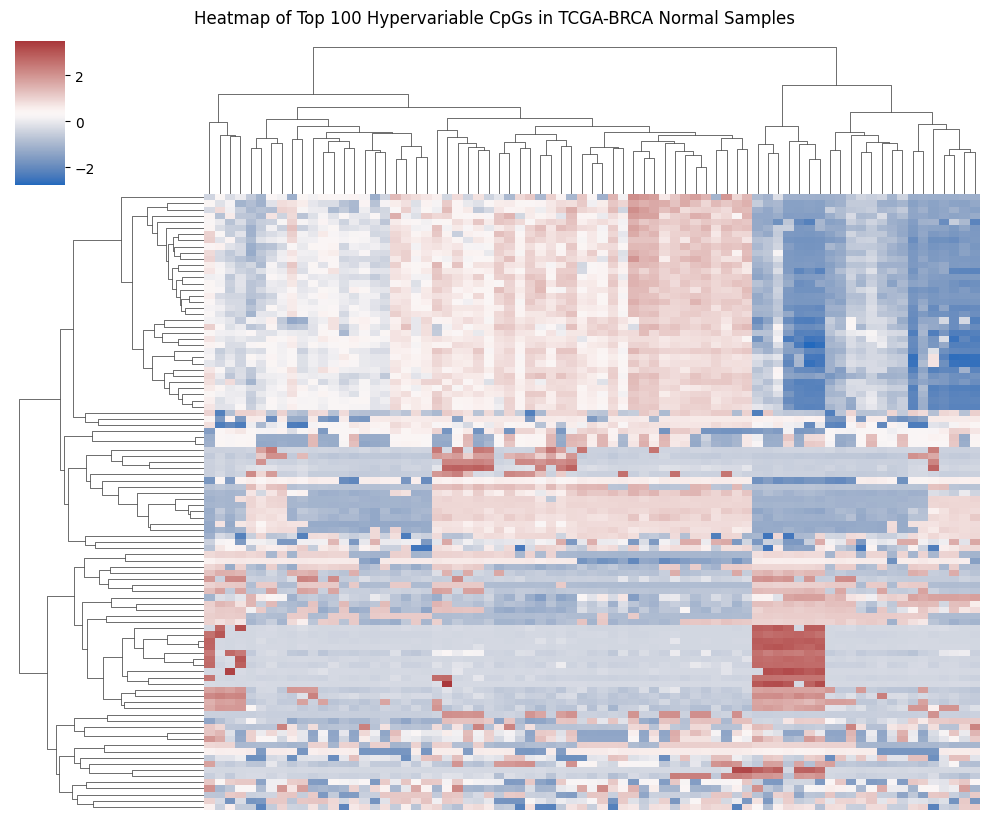

In [21]:
# We use standard scaling (z-score) across rows to see highlight variations clearly
g = sns.clustermap(
    beta_val_1k, 
    cmap="vlag", 
    z_score=0, 
    metric="euclidean", 
    method="complete", 
    figsize=(10, 8),
    xticklabels=False, # Hide individual sample IDs if they overcrowd the plot
    yticklabels=False  # Hide individual CpG IDs
)
g.fig.suptitle("Heatmap of Top 100 Hypervariable CpGs in TCGA-BRCA Normal Samples", y=1.02)
plt.savefig("results/plots/Hypervariable_CpGs.png")
plt.show()

# Find Age-Associated CpGs:
### There are 3 files. Clinical (age, submitter_id, case_id), Metadata.json (Alsmost all the metadata info), sample sheet (mapping file to map data file name/beta column names with case id (submitter id in clinical file) and sampleid))

In [22]:
clinical_normal = pd.read_csv("Normal_metadata/clinical.cart.2026-06-07/clinical.tsv", sep = '\t')
clinical_normal.head(3)

,project.project_id,cases.case_id,cases.consent_type,cases.days_to_consent,cases.days_to_lost_to_followup,cases.disease_type,cases.index_date,cases.lost_to_followup,cases.primary_site,cases.submitter_id,...,treatments.treatment_duration,treatments.treatment_effect,treatments.treatment_effect_indicator,treatments.treatment_frequency,treatments.treatment_id,treatments.treatment_intent_type,treatments.treatment_or_therapy,treatments.treatment_outcome,treatments.treatment_outcome_duration,treatments.treatment_type
0,TCGA-BRCA,02bbb632-0f7f-439d-b8f0-c86a06237424,Informed Consent,44,'--,Ductal and Lobular Neoplasms,Diagnosis,No,Breast,TCGA-AC-A2FB,...,'--,'--,'--,'--,03ba2fac-21e3-4e58-94d4-287560b8756f,'--,yes,Complete Response,'--,Hormone Therapy
1,TCGA-BRCA,02bbb632-0f7f-439d-b8f0-c86a06237424,Informed Consent,44,'--,Ductal and Lobular Neoplasms,Diagnosis,No,Breast,TCGA-AC-A2FB,...,'--,'--,'--,'--,16486505-f2b2-46fb-8880-5e0bfe77920a,Adjuvant,no,'--,'--,"Radiation Therapy, NOS"
2,TCGA-BRCA,02bbb632-0f7f-439d-b8f0-c86a06237424,Informed Consent,44,'--,Ductal and Lobular Neoplasms,Diagnosis,No,Breast,TCGA-AC-A2FB,...,'--,'--,'--,'--,173a8563-7ef7-46bb-8598-3937d0766a30,First-Line Therapy,yes,'--,'--,"Surgery, NOS"


In [23]:
list(clinical_normal.columns)

['project.project_id',
 'cases.case_id',
 'cases.consent_type',
 'cases.days_to_consent',
 'cases.days_to_lost_to_followup',
 'cases.disease_type',
 'cases.index_date',
 'cases.lost_to_followup',
 'cases.primary_site',
 'cases.submitter_id',
 'demographic.age_at_index',
 'demographic.age_is_obfuscated',
 'demographic.cause_of_death',
 'demographic.cause_of_death_source',
 'demographic.country_of_birth',
 'demographic.country_of_residence_at_enrollment',
 'demographic.days_to_birth',
 'demographic.days_to_death',
 'demographic.demographic_id',
 'demographic.education_level',
 'demographic.ethnicity',
 'demographic.gender',
 'demographic.marital_status',
 'demographic.occupation_duration_years',
 'demographic.population_group',
 'demographic.race',
 'demographic.sex_at_birth',
 'demographic.submitter_id',
 'demographic.vital_status',
 'demographic.year_of_birth',
 'demographic.year_of_death',
 'diagnoses.adrenal_hormone',
 'diagnoses.age_at_diagnosis',
 'diagnoses.ajcc_clinical_m',
 'dia

In [24]:
clinical_filt = clinical_normal[clinical_normal["demographic.age_is_obfuscated"] == "false"]
clinical_filt.head()

,project.project_id,cases.case_id,cases.consent_type,cases.days_to_consent,cases.days_to_lost_to_followup,cases.disease_type,cases.index_date,cases.lost_to_followup,cases.primary_site,cases.submitter_id,...,treatments.treatment_duration,treatments.treatment_effect,treatments.treatment_effect_indicator,treatments.treatment_frequency,treatments.treatment_id,treatments.treatment_intent_type,treatments.treatment_or_therapy,treatments.treatment_outcome,treatments.treatment_outcome_duration,treatments.treatment_type
0,TCGA-BRCA,02bbb632-0f7f-439d-b8f0-c86a06237424,Informed Consent,44,'--,Ductal and Lobular Neoplasms,Diagnosis,No,Breast,TCGA-AC-A2FB,...,'--,'--,'--,'--,03ba2fac-21e3-4e58-94d4-287560b8756f,'--,yes,Complete Response,'--,Hormone Therapy
1,TCGA-BRCA,02bbb632-0f7f-439d-b8f0-c86a06237424,Informed Consent,44,'--,Ductal and Lobular Neoplasms,Diagnosis,No,Breast,TCGA-AC-A2FB,...,'--,'--,'--,'--,16486505-f2b2-46fb-8880-5e0bfe77920a,Adjuvant,no,'--,'--,"Radiation Therapy, NOS"
2,TCGA-BRCA,02bbb632-0f7f-439d-b8f0-c86a06237424,Informed Consent,44,'--,Ductal and Lobular Neoplasms,Diagnosis,No,Breast,TCGA-AC-A2FB,...,'--,'--,'--,'--,173a8563-7ef7-46bb-8598-3937d0766a30,First-Line Therapy,yes,'--,'--,"Surgery, NOS"
3,TCGA-BRCA,02bbb632-0f7f-439d-b8f0-c86a06237424,Informed Consent,44,'--,Ductal and Lobular Neoplasms,Diagnosis,No,Breast,TCGA-AC-A2FB,...,'--,'--,'--,'--,b323df74-e75f-435d-bd9e-5a51533cc6dc,'--,yes,Complete Response,'--,Chemotherapy
4,TCGA-BRCA,02bbb632-0f7f-439d-b8f0-c86a06237424,Informed Consent,44,'--,Ductal and Lobular Neoplasms,Diagnosis,No,Breast,TCGA-AC-A2FB,...,'--,'--,'--,'--,f85dc5a6-ef34-58cb-bc5a-7160da00e74b,'--,yes,Complete Response,'--,Chemotherapy


In [25]:
# Check if the columns order in clinical and beta matches.
print(beta_normal.columns[1:5])
print(clinical_normal['cases.submitter_id'].head())

Index(['TCGA-BH-A0B8-11A', 'TCGA-BH-A0C3-11A', 'TCGA-A7-A13E-11A',
       'TCGA-BH-A1EU-11A'],
      dtype='object')
0    TCGA-AC-A2FB
1    TCGA-AC-A2FB
2    TCGA-AC-A2FB
3    TCGA-AC-A2FB
4    TCGA-AC-A2FB
Name: cases.submitter_id, dtype: object


In [26]:
print(beta_normal.shape)
print(clinical_normal.shape)

print(beta_normal.columns[:5])

print(
    clinical_normal[
        ['cases.submitter_id',
         'demographic.age_at_index']
    ].head()
)
print(
    sample_sheet_normal[
        ['Case ID',
         'File Name']
    ].head()
)

(367665, 77)
(309, 201)
Index(['CpG', 'TCGA-BH-A0B8-11A', 'TCGA-BH-A0C3-11A', 'TCGA-A7-A13E-11A',
       'TCGA-BH-A1EU-11A'],
      dtype='object')
  cases.submitter_id  demographic.age_at_index
0       TCGA-AC-A2FB                        65
1       TCGA-AC-A2FB                        65
2       TCGA-AC-A2FB                        65
3       TCGA-AC-A2FB                        65
4       TCGA-AC-A2FB                        65
        Case ID                                          File Name
0  TCGA-BH-A1F5  e5e37029-fb06-4e34-b3b2-277854b8f59a.methylati...
1  TCGA-BH-A1FB  d65249d9-4d0c-4a47-aee2-6d7c59b6ef8b.methylati...
2  TCGA-E9-A1NF  79512f6f-1092-46d8-863c-5a9d052549b1.methylati...
3  TCGA-BH-A1ES  ad1210ef-7129-4e3a-8c17-8c14e0381920.methylati...
4  TCGA-BH-A1EW  4af95eed-bfde-42c1-8e5f-d2aefa7bc55b.methylati...


In [27]:
clinical_age_normal = clinical_normal[
    ['cases.submitter_id',
     'demographic.age_at_index']
].drop_duplicates()

print(clinical_age_normal.shape)

(75, 2)


In [28]:
clinical_age_normal.head()

,cases.submitter_id,demographic.age_at_index
0,TCGA-AC-A2FB,65
5,TCGA-BH-A204,80
6,TCGA-BH-A1EY,79
10,TCGA-BH-A0DG,30
15,TCGA-BH-A0H9,69


In [29]:
beta_normal.columns[:3]

Index(['CpG', 'TCGA-BH-A0B8-11A', 'TCGA-BH-A0C3-11A'], dtype='object')

## Convert Sample IDs to Patient IDs

In [30]:
sample_ids = beta_normal.columns[1:-1]
patient_ids = [s[:12] for s in sample_ids]

# Split by hyphen, take the first 3 elements (Project-TSS-Participant), and join them
# patient_ids = sample_ids.to_series().str.split('-').str[:3].str.join('-').tolist()

patient_ids[:3]

['TCGA-BH-A0B8', 'TCGA-BH-A0C3', 'TCGA-A7-A13E']

In [31]:
clinical_age_normal["cases.submitter_id"].head()

0     TCGA-AC-A2FB
5     TCGA-BH-A204
6     TCGA-BH-A1EY
10    TCGA-BH-A0DG
15    TCGA-BH-A0H9
Name: cases.submitter_id, dtype: object

## Match ages: Mapping the beta columns with clinical data submitter id and respective age

In [32]:
age_dic = dict(
    zip(
        clinical_age_normal["cases.submitter_id"],
        clinical_age_normal["demographic.age_at_index"]
    )
)

ages = pd.Series(
    [age_dic[p] for p in patient_ids],
    index = [sample_ids]
)

# ages = pd.Series(
#     patient_ids_tumor, index= sample_ids_tumor
# )

# # map the key of the dictionary (submitter id) with the index of the series (sample_ids) 
# ages = ages.map(age_dic)
ages.head()

TCGA-BH-A0B8-11A    64
TCGA-BH-A0C3-11A    47
TCGA-A7-A13E-11A    62
TCGA-BH-A1EU-11A    83
TCGA-BH-A0E0-11A    38
dtype: int64

In [33]:
# Check if the column names of your matrix exactly match the index of your ages series
print("Are samples actually aligned?", list(beta_normal.columns[1:-1]) == list(ages.index.get_level_values(0)))

Are samples actually aligned? True


## Plot PCA

### Question 1: Are there outlier samples? :If older samples gradually shift along PC1 or PC2, age is one major source of variation.

In [34]:
x = beta_val_1k.T

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

pca = PCA(n_components=2)

pcs = pca.fit_transform(x_scaled)

In [35]:
pca

PCA(n_components=2)

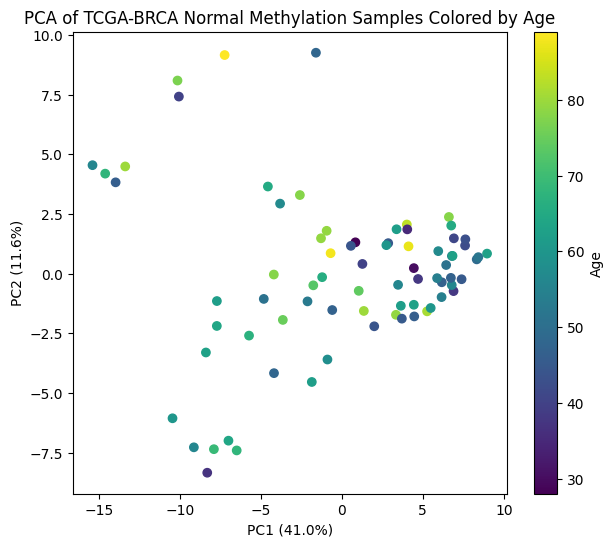

In [36]:
pca_df = pd.DataFrame({
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
    "sample_id": x.index
})

pca_df["patient_id"] = pca_df["sample_id"].str[:12]
pca_df["age"] = pca_df["patient_id"].map(age_dic)

plt.figure(figsize=(7, 6))
sc = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["age"],
    cmap="viridis"
)
plt.colorbar(sc, label="Age")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of TCGA-BRCA Normal Methylation Samples Colored by Age")
plt.savefig("results/plots/TCGA-BRCA_normal_meth_samples_color_by_age.png")
plt.show()

### Question 2: Is age driving global methylation variation? : correlation between PC axes and ages

In [37]:
for pc in ["PC1", "PC2"]:
    r, p = pearsonr(pca_df[pc], pca_df["age"])
    print(pc, "correlation with age:", r, "p:", p)

PC1 correlation with age: -0.2352629169771465 p: 0.04217079380302858
PC2 correlation with age: 0.09225251892195849 p: 0.4311693663151538


### Question 3: Are samples clustering by preservation method or batch?

``` If OCT and Unknown form separate clusters, technical effects may exist. ```

In [38]:
pca_df = pca_df.merge(
    sample_sheet_normal[["Sample ID", "Preservation Method"]],
    left_on="sample_id",
    right_on="Sample ID",
    how="left"
)

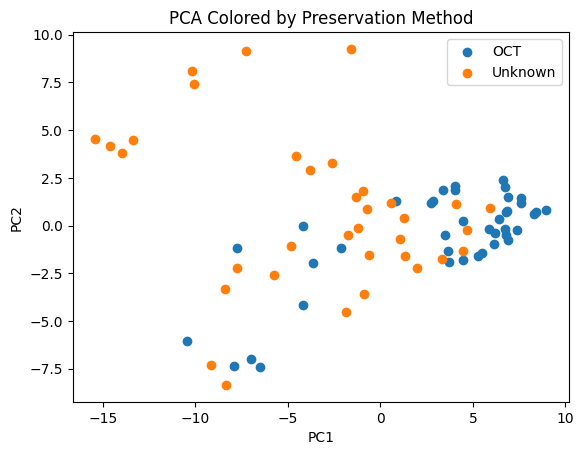

In [39]:
for method in pca_df["Preservation Method"].dropna().unique():
    subset = pca_df[pca_df["Preservation Method"] == method]
    plt.scatter(subset["PC1"], subset["PC2"], label=method)

plt.legend()
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Colored by Preservation Method")
plt.savefig("results/plots/TCGA-BRCA_normal_color_by_preserved_method.png")
plt.show()

## calculate correlations : CpG methylation vs Age

``` 1. Which CpGs gain methylation with age? ```

``` 2. Which CpGs lose methylation with age? ```

``` 3. Is there a strong age signal in normal breast tissue? ```

In [40]:
X = beta_normal.iloc[:,1:-1].to_numpy(dtype=np.float32)

r = np.empty(X.shape[0], dtype=np.float32)
p = np.empty(X.shape[0], dtype=np.float32)

for i in range(X.shape[0]):
    r[i], p[i] = pearsonr(X[i], ages.values)

results_df = pd.DataFrame({
    "CpG": beta_normal["CpG"],
    "r": r,
    "p": p
})

results_df = results_df.sort_values("p")

In [41]:
results_df.head()

,CpG,r,p
401279,cg22736354,0.805268,3.076264e-18
71686,cg03545227,0.800154,7.187889e-18
415518,cg23606718,0.787306,5.463797e-17
120426,cg06121469,0.780700,1.469346e-16
116616,cg05917988,0.775668,3.051956e-16


In [42]:
results_df["FDR"] = multipletests(
    results_df["p"],
    method = "fdr_bh"
)[1]

results_df = results_df.sort_values(
    "FDR"
)

results_df.head()

,CpG,r,p,FDR
401279,cg22736354,0.805268,3.076264e-18,1.131035e-12
71686,cg03545227,0.800154,7.187889e-18,1.321368e-12
415518,cg23606718,0.787306,5.463797e-17,6.696157e-12
120426,cg06121469,0.780700,1.469346e-16,1.350568e-11
116616,cg05917988,0.775668,3.051956e-16,2.244195e-11


In [43]:
(results_df["FDR"] < 0.05).sum()

np.int64(1330)

In [44]:
(results_df["r"].abs() >=0.5).sum()

np.int64(421)

### Plot 1: Volcano-like correlation plot

``` 1. Are age-associated CpGs mostly positively or negatively correlated with age? ```

``` 2. How strong are the age associations? ```

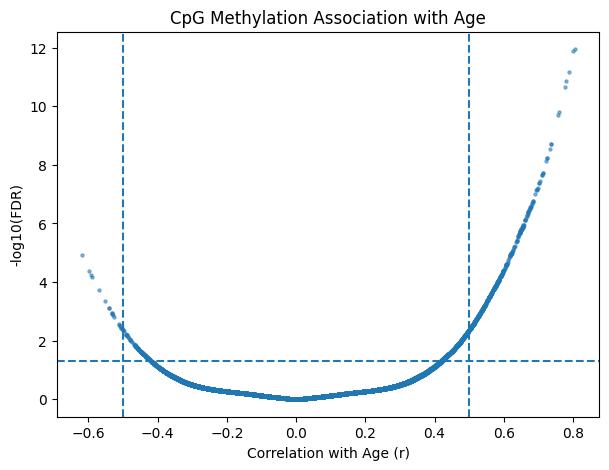

In [45]:
results_df["neg_log10_FDR"] = -np.log10(results_df["FDR"])

plt.figure(figsize=(7, 5))
plt.scatter(
    results_df["r"],
    results_df["neg_log10_FDR"],
    s=5,
    alpha=0.5
)
plt.axvline(0.5, linestyle="--")
plt.axvline(-0.5, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")
plt.xlabel("Correlation with Age (r)")
plt.ylabel("-log10(FDR)")
plt.title("CpG Methylation Association with Age")
plt.savefig("results/plots/CpG_Meth_Association_with_Age.png")
plt.show()

### Plot 2: Top positive CpGs: methylation increasing with age at important CpGs?

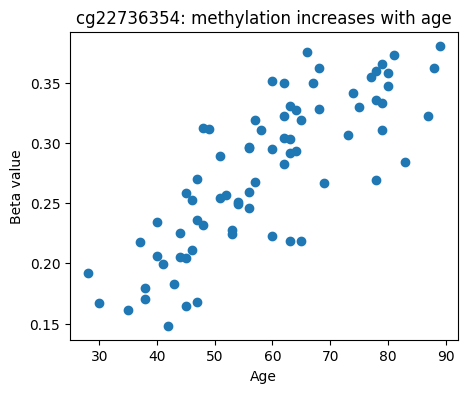

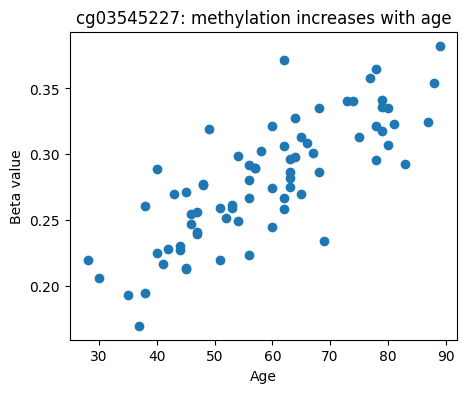

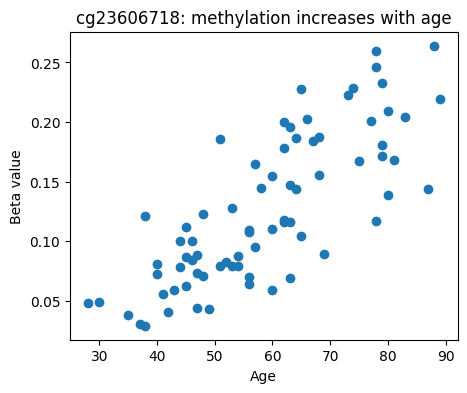

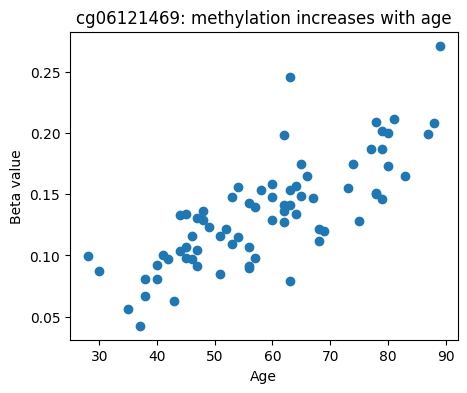

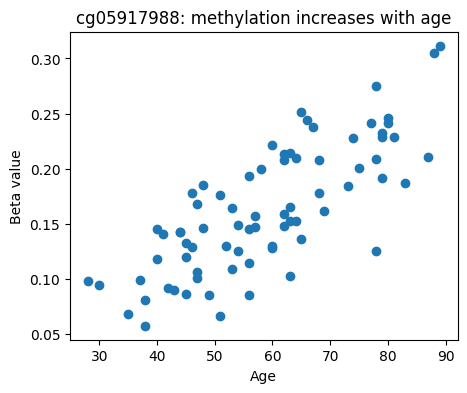

In [46]:
top_positive = results_df.sort_values("r", ascending=False).head(5)

for cpg in top_positive["CpG"]:
    values = beta_normal.loc[beta_normal["CpG"] == cpg, beta_normal.columns[1:-1]].values.flatten()
    sample_ids = beta_normal.columns[1:-1]
    patient_ids = [s[:12] for s in sample_ids]
    ages_plot = [age_dic[p] for p in patient_ids]

    plt.figure(figsize=(5, 4))
    plt.scatter(ages_plot, values)
    plt.xlabel("Age")
    plt.ylabel("Beta value")
    plt.title(f"{cpg}: methylation increases with age")
    plt.show()

### Plot 3: Top negative CpGs: Which CpGs lose methylation with age?

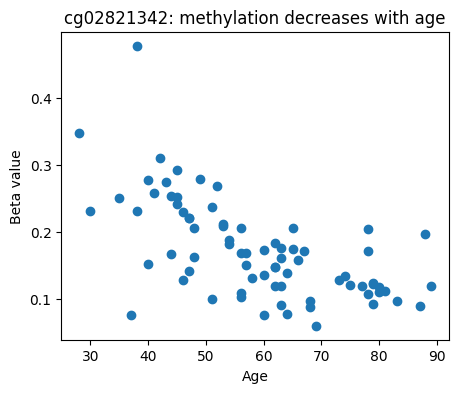

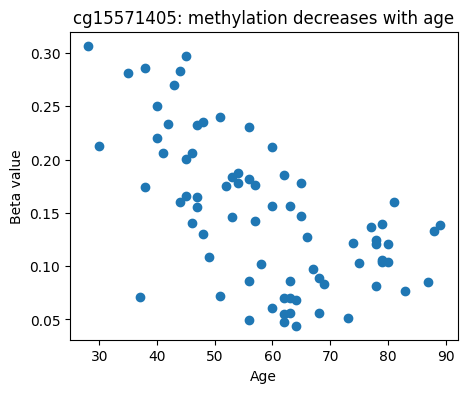

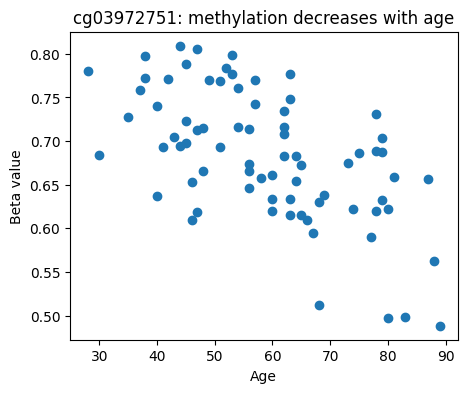

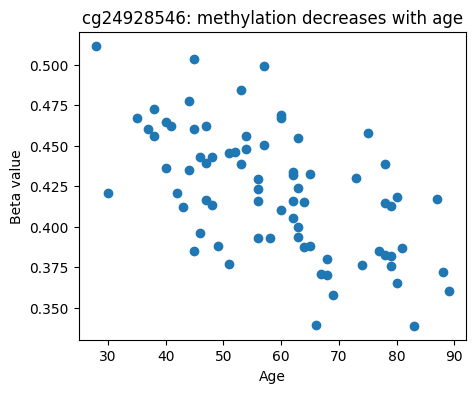

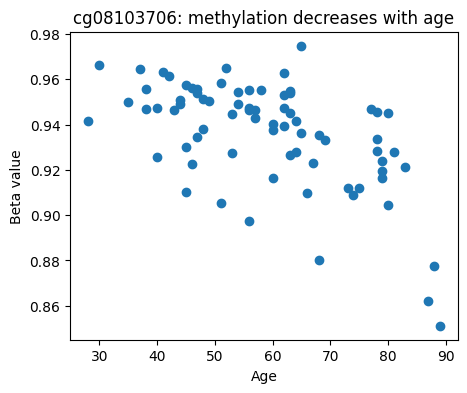

In [47]:
top_positive = results_df.sort_values("r").head(5)

for cpg in top_positive["CpG"]:
    values = beta_normal.loc[beta_normal["CpG"] == cpg, beta_normal.columns[1:-1]].values.flatten()
    sample_ids = beta_normal.columns[1:-1]
    patient_ids = [s[:12] for s in sample_ids]
    ages_plot = [age_dic[p] for p in patient_ids]

    plt.figure(figsize=(5, 4))
    plt.scatter(ages_plot, values)
    plt.xlabel("Age")
    plt.ylabel("Beta value")
    plt.title(f"{cpg}: methylation decreases with age")
    plt.show()

# Check if the known CpGs are part of the top positive CpGs or not

In [48]:
# cg16867657: ELOVL2: This is universally recognized as the single most powerful chronological aging marker in the human genome.
# cg22454530: FHL2: Located in the promoter of the Four-and-a-Half LIM Domains 2 gene, this CpG island exhibits a steady, robust gain of methylation over time across multiple tissue types, including healthy breast tissue

#beta_normal.loc[beta_normal["CpG"] == "cg22454530"]

In [49]:
# results_df.loc[results_df["CpG"] == "cg22454530"]

# Feature selection: Filter candidate CpGs i.e CpGs having high correlation with age

In [50]:
candidate_cpgs = results_df[
    (results_df["FDR"] < 0.05) &
    (results_df["r"].abs() > 0.5)
]

print(candidate_cpgs.shape)

(421, 5)


In [51]:
candidate_cpgs.head()

,CpG,r,p,FDR,neg_log10_FDR
401279,cg22736354,0.805268,3.076264e-18,1.131035e-12,11.946524
71686,cg03545227,0.800154,7.187889e-18,1.321368e-12,11.878976
415518,cg23606718,0.787306,5.463797e-17,6.696157e-12,11.174174
120426,cg06121469,0.780700,1.469346e-16,1.350568e-11,10.869484
116616,cg05917988,0.775668,3.051956e-16,2.244195e-11,10.648939


## Inspect the Candidate Set

In [52]:
candidate_cpgs["r"].abs().describe()

count    421.000000
mean       0.574978
std        0.063162
min        0.500050
25%        0.524686
50%        0.560831
75%        0.608458
max        0.805268
Name: r, dtype: float64

In [53]:
candidate_cpgs.sort_values(
    "r",
    ascending = False
).head(10)

,CpG,r,p,FDR,neg_log10_FDR
401279,cg22736354,0.805268,3.076264e-18,1.131035e-12,11.946524
71686,cg03545227,0.800154,7.187889e-18,1.321368e-12,11.878976
415518,cg23606718,0.787306,5.463797e-17,6.696157e-12,11.174174
120426,cg06121469,0.780700,1.469346e-16,1.350568e-11,10.869484
116616,cg05917988,0.775668,3.051956e-16,2.244195e-11,10.648939
112840,cg05708550,0.760303,2.542845e-15,1.558192e-10,9.807379
47600,cg02331561,0.757517,3.672078e-15,1.928707e-10,9.714734
387462,cg21801378,0.738031,4.209641e-14,1.913243e-09,8.718230
97378,cg04880546,0.737137,4.683392e-14,1.913243e-09,8.718230
230541,cg12373771,0.732802,7.810418e-14,2.871617e-09,8.541873


In [54]:
candidate_cpgs.sort_values(
    "r"
).head(10)

,CpG,r,p,FDR,neg_log10_FDR
57356,cg02821342,-0.619937,3.013187e-09,0.000012,4.933245
287546,cg15571405,-0.598727,1.396570e-08,0.000042,4.375845
79890,cg03972751,-0.593215,2.043197e-08,0.000058,4.238181
437220,cg24928546,-0.590132,2.520092e-08,0.000067,4.173010
157248,cg08103706,-0.569798,9.529952e-08,0.000185,3.731919
417694,cg23728447,-0.552067,2.831175e-07,0.000441,3.355493
169867,cg08804626,-0.540053,5.716673e-07,0.000799,3.097356
245208,cg13306815,-0.540051,5.717309e-07,0.000799,3.097356
139898,cg07155013,-0.532363,8.837886e-07,0.001124,2.949097
324879,cg17824540,-0.531383,9.335540e-07,0.001180,2.928301


# Build the Feature Matrix

In [55]:
# Extract CpGs

selected_cpgs = candidate_cpgs["CpG"]

clock_df = beta_normal[
    beta_normal["CpG"].isin(selected_cpgs)
].copy()

clock_df = clock_df.iloc[:, :-1]
clock_df.shape

(421, 76)

## Create X and y

### Convert to machine learning format: current str = CpG * Samples, ML requires: Samples * CpG

In [56]:
X = clock_df.set_index("CpG").T

X.shape

(75, 421)

In [57]:
X.head()

CpG,cg00032205,cg00059225,cg00065935,cg00068155,cg00088042,cg00221745,cg00250500,cg00252781,cg00321234,cg00394316,...,cg26856080,cg26885220,cg26921969,cg26956371,cg26974111,cg27290215,cg27320127,cg27343616,cg27587125,cg27639942
TCGA-BH-A0B8-11A,0.185410,0.303393,0.106753,0.124709,0.075646,0.029827,0.126389,0.198818,0.419453,0.152028,...,0.035607,0.047587,0.262512,0.040198,0.114731,0.260471,0.181601,0.163475,0.095732,0.105360
TCGA-BH-A0C3-11A,0.160918,0.267807,0.096055,0.100652,0.054230,0.025514,0.135298,0.219342,0.542348,0.258886,...,0.029464,0.042097,0.200871,0.026736,0.181071,0.507681,0.141023,0.183561,0.150060,0.146270
TCGA-A7-A13E-11A,0.186195,0.330057,0.081909,0.123529,0.059262,0.023828,0.101673,0.139639,0.527559,0.089089,...,0.023625,0.012019,0.249967,0.018069,0.146360,0.414990,0.147529,0.188586,0.080087,0.121437
TCGA-BH-A1EU-11A,0.196369,0.328200,0.095587,0.132849,0.089343,0.018681,0.051179,0.290565,0.273430,0.313095,...,0.019926,0.021035,0.219537,0.038508,0.145568,0.256078,0.135064,0.202838,0.148236,0.155308
TCGA-BH-A0E0-11A,0.143813,0.192637,0.048724,0.078966,0.043005,0.012951,0.048100,0.101415,0.487536,0.140394,...,0.018780,0.013267,0.178935,0.009856,0.160632,0.483730,0.098300,0.167999,0.090454,0.091468


In [58]:
ages.head()

TCGA-BH-A0B8-11A    64
TCGA-BH-A0C3-11A    47
TCGA-A7-A13E-11A    62
TCGA-BH-A1EU-11A    83
TCGA-BH-A0E0-11A    38
dtype: int64

In [59]:
y = ages.loc[X.index]

In [60]:
print(X.shape)
print(y.shape)

(75, 421)
(75,)


## First Prototype Clock

### Train-Test split

In [61]:
# from sklearn.model_selection import train_test_split

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size= 0.2,
    random_state= 42
)

In [63]:
len(X_train)

60

In [64]:
len(X_test)

15

### Train Elastic Net

In [65]:
# from sklearn.linear_model import ElasticNetCV

In [66]:
model = ElasticNetCV(
    l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    cv = 5,
    max_iter = 10000,
    random_state = 42
)

model.fit(X_train, y_train)

ElasticNetCV(cv=5, l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0], max_iter=10000,
             random_state=42)

### Evaluate the Clock

In [67]:
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

In [68]:
normal_pred = model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    normal_pred
)

r2 = r2_score(
    y_test,
    normal_pred
)

print("MAE: " , mae)
print("R2: ", r2)

MAE:  5.114640235900879
R2:  0.8768999576568604


## Visualize Predicted vs Actual Age

``` Does the clock predict age well in unseen normal samples? ```

``` Is prediction biased for younger or older patients? ```

``` Are there outlier predictions? ```

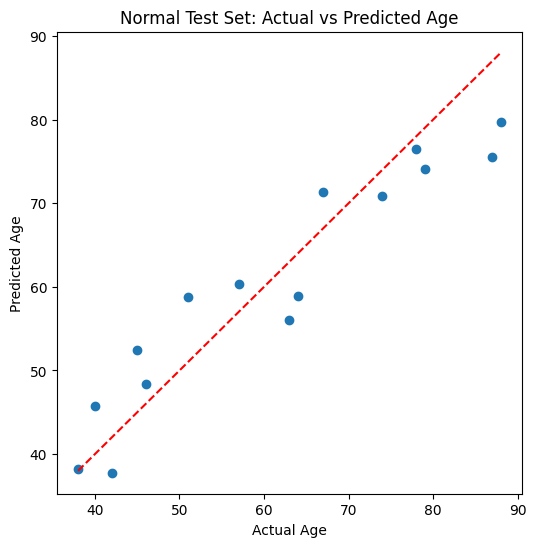

In [69]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, normal_pred)

plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Normal Test Set: Actual vs Predicted Age")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.savefig("results/plots/Predicted_vs_Actual_age.png")
plt.show()

In [70]:
r,_ = pearsonr(y_test, normal_pred)

print(r)

0.9483767987370672


In [71]:
normal_results = pd.DataFrame({
    "actual_age": y_test,
    "predicted_age": normal_pred
})

normal_results["age_acceleration"] = (
    normal_results["predicted_age"]
    - normal_results["actual_age"]
)

In [72]:
normal_results["age_acceleration"].describe()

count    15.000000
mean     -0.961139
std       5.967772
min     -11.502060
25%      -5.030426
50%      -1.483521
75%       3.830708
max       7.752533
Name: age_acceleration, dtype: float64

## Check how many CpGs Elastic Net actually keeps:

In [73]:
coef = pd.Series(
    model.coef_,
    index=X.columns
)

selected = coef[coef != 0]

print("Selected CpGs:", len(selected))

Selected CpGs: 390


## Save the Clock Signature: Extract retained CpGs

In [74]:
coef = pd.Series(
    model.coef_,
    index=X.columns
)

clock_cpgs = coef[
    coef != 0
].sort_values(
    key=abs,
    ascending=False
)

clock_cpgs.to_csv(
    "results/tables/Epigenetic_Clock_CpGs.csv"
)

# Tumor samples: application set

In [75]:
input_dir = "TCGA_tumor_beta_files/gdc_download"

files = glob.glob(
    os.path.join(input_dir, "**/*methylation_array.sesame.level3betas.txt"),
    recursive=True
)

print(f"Found {len(files)} files")

dfs = []
for f in files[:10]:
    df = pd.read_csv(f, sep="\t", header=None)
    print(os.path.basename(f), df.shape)

Found 284 files
21dec346-790d-4de7-a706-45a0149b9c31.methylation_array.sesame.level3betas.txt (486427, 2)
1a1d9f5b-1de1-43f2-96e7-8dd8ae7459c6.methylation_array.sesame.level3betas.txt (486427, 2)
5939bd66-c8f4-4d2b-a3c6-880dd578db90.methylation_array.sesame.level3betas.txt (486427, 2)
594a11ae-8cc3-4989-8416-20d7b9e32850.methylation_array.sesame.level3betas.txt (486427, 2)
eb0ed99c-82d6-4908-8510-f012163841c4.methylation_array.sesame.level3betas.txt (486427, 2)
1ffe8243-db7c-4068-a4d0-18dfeb40c4e4.methylation_array.sesame.level3betas.txt (486427, 2)
c41f545b-c284-4554-8851-0c386b30dcb6.methylation_array.sesame.level3betas.txt (486427, 2)
004060cf-4360-49cb-a1f9-651bf55c6e0f.methylation_array.sesame.level3betas.txt (486427, 2)
254d88a5-5030-4ee0-9773-794d33579884.methylation_array.sesame.level3betas.txt (486427, 2)
e49b3fc7-3a27-452f-9151-cb822ae121f5.methylation_array.sesame.level3betas.txt (486427, 2)


In [76]:
sample_sheet_tumor = pd.read_csv("Tumor_metadata/gdc_sample_sheet.2026-06-24.tsv", sep = '\t')
sample_sheet_tumor.head(3)

,File ID,File Name,Data Category,Data Type,Project ID,Case ID,Sample ID,Tissue Type,Tumor Descriptor,Specimen Type,Preservation Method
0,c53cc045-bced-4c5f-97e7-b17ab835ef23,d8c6fdeb-4aba-4a11-b62e-d587dadbcc62.methylati...,DNA Methylation,Methylation Beta Value,TCGA-BRCA,TCGA-AR-A2LR,TCGA-AR-A2LR-01A,Tumor,Primary,Solid Tissue,OCT
1,8e48755a-490f-45b4-b1bf-0fbf09485177,27fe0b6c-1b76-400b-a0ef-9405f833c482.methylati...,DNA Methylation,Methylation Beta Value,TCGA-BRCA,TCGA-AQ-A0Y5,TCGA-AQ-A0Y5-01A,Tumor,Primary,Solid Tissue,Unknown
2,2cd4820b-b104-4bcd-801c-d19cb0b749ba,fa1b44dd-3960-4ce1-be3c-2e2e0e7ece66.methylati...,DNA Methylation,Methylation Beta Value,TCGA-BRCA,TCGA-D8-A1XU,TCGA-D8-A1XU-01A,Tumor,Primary,Solid Tissue,Unknown


In [77]:
sample_sheet_tumor.columns

Index(['File ID', 'File Name', 'Data Category', 'Data Type', 'Project ID',
       'Case ID', 'Sample ID', 'Tissue Type', 'Tumor Descriptor',
       'Specimen Type', 'Preservation Method'],
      dtype='object')

In [78]:
# ----------------------------
# Read sample sheet
# ----------------------------
sample_sheet_tumor = pd.read_csv(
    "Tumor_metadata/gdc_sample_sheet.2026-06-24.tsv",
    sep="\t"
)

# Create filename -> Sample ID mapping
file_to_sample = dict(
    zip(sample_sheet_tumor["File Name"],
        sample_sheet_tumor["Sample ID"])
)

input_dir = "TCGA_tumor_beta_files/gdc_download"

files = glob.glob(
    os.path.join(
        input_dir,
        "**/*methylation_array.sesame.level3betas.txt"
    ),
    recursive=True
)

# Read first file
first = pd.read_csv(
    files[0],
    sep="\t",
    header=None,
    names=["CpG", "beta"]
)

beta_tumor = pd.DataFrame()
beta_tumor["CpG"] = first["CpG"]

#print(beta)

for f in files:

    filename = os.path.basename(f)

    sample_id = file_to_sample[filename]

    df = pd.read_csv(
        f,
        sep="\t",
        header=None,
        names=["CpG", sample_id],
        dtype={sample_id: "float32"}
    )

    beta_tumor[sample_id] = df[sample_id]

print(beta_tumor.shape)

/tmp/ipykernel_11549/3558993654.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  beta_tumor[sample_id] = df[sample_id]
/tmp/ipykernel_11549/3558993654.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  beta_tumor[sample_id] = df[sample_id]
/tmp/ipykernel_11549/3558993654.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, us

(486427, 285)


/tmp/ipykernel_11549/3558993654.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  beta_tumor[sample_id] = df[sample_id]


## Remove Missing beta values

In [79]:
beta_tumor.isna().sum().sum()

np.int64(21557979)

In [80]:
beta_tumor = beta_tumor.dropna()
print(beta_tumor.shape)

(331412, 285)


# Beta value distribution

## Hist plot

In [81]:
beta_tumor.head(3)

,CpG,TCGA-A2-A0YL-01A,TCGA-A2-A4RY-01A,TCGA-EW-A1PD-01A,TCGA-E9-A2JS-01A,TCGA-OL-A66N-01A,TCGA-AN-A0XS-01A,TCGA-AO-A03N-01B,TCGA-AR-A1AN-01A,TCGA-BH-A0BJ-01A,...,TCGA-LD-A7W6-01A,TCGA-E2-A105-01A,TCGA-E2-A1IF-01A,TCGA-C8-A278-01A,TCGA-A1-A0SB-01A,TCGA-AR-A1AQ-01A,TCGA-A7-A0D9-01A,TCGA-A2-A0YD-01A,TCGA-E2-A14N-01A,TCGA-E9-A1N9-01A
1,cg00000108,0.968855,0.954615,0.962705,0.967742,0.968813,0.952585,0.967970,0.969406,0.968968,...,0.974842,0.970717,0.953251,0.969744,0.961058,0.968807,0.976677,0.972759,0.963902,0.971166
2,cg00000109,0.888137,0.781154,0.861381,0.943306,0.907975,0.927612,0.951865,0.915327,0.933196,...,0.902002,0.931089,0.933716,0.911685,0.775980,0.932505,0.948036,0.910187,0.934058,0.934178
4,cg00000236,0.925575,0.908153,0.948760,0.895549,0.923423,0.939274,0.948556,0.922064,0.924324,...,0.899006,0.933906,0.897305,0.924397,0.821440,0.919827,0.918382,0.931590,0.929213,0.906086


In [82]:
values = beta_tumor.iloc[:, 1:].values.flatten()
values

array([0.9688546 , 0.95461476, 0.9627055 , ..., 0.9497669 , 0.94844013,
       0.9581664 ], shape=(94121008,), dtype=float32)

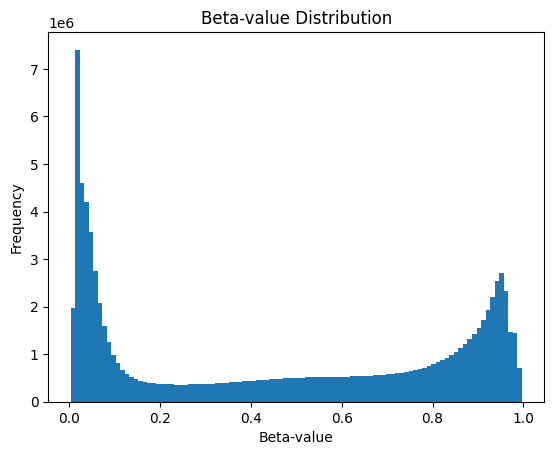

In [83]:
plt.hist(values, bins = 100)
plt.xlabel("Beta-value")
plt.ylabel("Frequency")
plt.title("Beta-value Distribution")
plt.savefig("results/plots/Beta_value-Tumor.png")
plt.show()

## Density plot

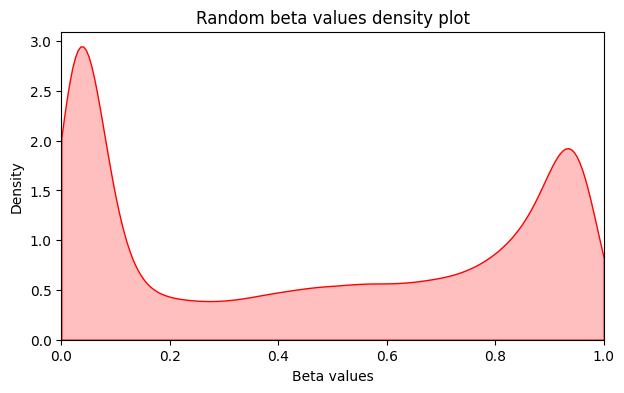

In [84]:
# 1. Flatten and randomly sample 100,000 points (visually identical to plotting all 27M)

random_beta_tumor = np.random.choice(beta_tumor.iloc[:, 1:].values.flatten(), size=100000, replace=False)

# 2. Plot as a smooth density curve

plt.figure(figsize= (7,4))
sns.kdeplot(random_beta_tumor, fill = True, color="red", clip=(0.0, 1.0))
plt.title("Random beta values density plot")
plt.xlabel("Beta values")
plt.ylabel("Density")
plt.xlim(0,1)
plt.savefig("results/plots/Random_beta_values_density_plot.png")
plt.show()

# Calculate variance: Most variable CpGs

In [85]:
# beta_tumor["variance"] = beta_tumor.iloc[:, 1:].var(axis = 1)
# beta_tumor["variance"].shape

In [86]:
# top_var_cpgs = beta_tumor.sort_values("variance", ascending=False)
# top_var_cpgs = top_var_cpgs.head(100)

In [87]:
# top_var_cpgs.to_csv("Top_100_variable_CpGs_in_tumor_samples.csv", index = False)

In [88]:
# top_var_cpgs.shape

# Plotting 100 most variable CpGs

In [89]:
# cpgs_100 = top_var_cpgs.iloc[:,0]
# beta_values_100 = top_var_cpgs.iloc[:, 1:-1]
# cpgs_100.head()

In [90]:
# beta_values_100.head()

## Clustered heatplot

In [91]:
# # We use standard scaling (z-score) across rows to see highlight variations clearly
# g = sns.clustermap(
#     beta_values_100, 
#     cmap="vlag", 
#     z_score=0, 
#     metric="euclidean", 
#     method="complete", 
#     figsize=(10, 8),
#     xticklabels=False, # Hide individual sample IDs if they overcrowd the plot
#     yticklabels=False  # Hide individual CpG IDs
# )
# g.fig.suptitle("Heatmap of Top 100 Hypervariable CpGs in TCGA-BRCA Tumor Samples", y=1.02)
# plt.savefig("Hypervariable_CpGs_tumor.png")
# plt.show()

## Plot PCA: Question 1: Are tumor samples globally different from normals?

In [92]:
x = beta_tumor.iloc[:, 1:-1]
x.head()

,TCGA-A2-A0YL-01A,TCGA-A2-A4RY-01A,TCGA-EW-A1PD-01A,TCGA-E9-A2JS-01A,TCGA-OL-A66N-01A,TCGA-AN-A0XS-01A,TCGA-AO-A03N-01B,TCGA-AR-A1AN-01A,TCGA-BH-A0BJ-01A,TCGA-B6-A0X4-01A,...,TCGA-A7-A426-01A,TCGA-LD-A7W6-01A,TCGA-E2-A105-01A,TCGA-E2-A1IF-01A,TCGA-C8-A278-01A,TCGA-A1-A0SB-01A,TCGA-AR-A1AQ-01A,TCGA-A7-A0D9-01A,TCGA-A2-A0YD-01A,TCGA-E2-A14N-01A
1,0.968855,0.954615,0.962705,0.967742,0.968813,0.952585,0.967970,0.969406,0.968968,0.976834,...,0.962344,0.974842,0.970717,0.953251,0.969744,0.961058,0.968807,0.976677,0.972759,0.963902
2,0.888137,0.781154,0.861381,0.943306,0.907975,0.927612,0.951865,0.915327,0.933196,0.957463,...,0.880732,0.902002,0.931089,0.933716,0.911685,0.775980,0.932505,0.948036,0.910187,0.934058
4,0.925575,0.908153,0.948760,0.895549,0.923423,0.939274,0.948556,0.922064,0.924324,0.922533,...,0.905736,0.899006,0.933906,0.897305,0.924397,0.821440,0.919827,0.918382,0.931590,0.929213
6,0.683334,0.682092,0.448892,0.598844,0.795119,0.889325,0.535199,0.475584,0.664838,0.489552,...,0.703564,0.726065,0.470243,0.660166,0.631669,0.481824,0.753368,0.911393,0.703456,0.697758
8,0.469766,0.320236,0.431313,0.363716,0.697211,0.444861,0.131618,0.386425,0.182716,0.089916,...,0.443690,0.226867,0.589184,0.314778,0.504123,0.084209,0.240806,0.088676,0.317464,0.257818


In [93]:
x = x.T

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

pca = PCA(n_components=2)

pcs = pca.fit_transform(x_scaled)

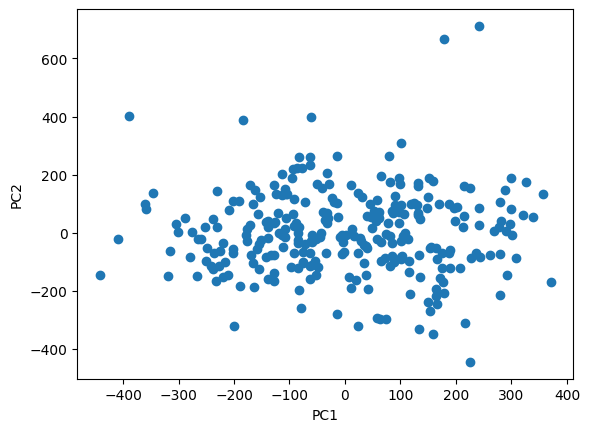

In [94]:
plt.scatter(
    pcs[:, 0],
    pcs[:, 1]
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig("results/plots/PCA_PLOT_Tumor_of_beta_values.png")
plt.show()

# Finding CpGs associated with age

In [95]:
clinical_tumor = pd.read_csv("Tumor_metadata/clinical.cart.2026-06-24/clinical.tsv", sep = '\t')
clinical_tumor.head(5)

,project.project_id,cases.case_id,cases.consent_type,cases.days_to_consent,cases.days_to_lost_to_followup,cases.disease_type,cases.index_date,cases.lost_to_followup,cases.primary_site,cases.submitter_id,...,treatments.treatment_duration,treatments.treatment_effect,treatments.treatment_effect_indicator,treatments.treatment_frequency,treatments.treatment_id,treatments.treatment_intent_type,treatments.treatment_or_therapy,treatments.treatment_outcome,treatments.treatment_outcome_duration,treatments.treatment_type
0,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,Informed Consent,-34,'--,Ductal and Lobular Neoplasms,Diagnosis,'--,Breast,TCGA-E2-A1IU,...,'--,'--,'--,'--,1b884f21-eb24-467f-aba2-208af17070b9,Adjuvant,no,'--,'--,"Radiation Therapy, NOS"
1,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,Informed Consent,-34,'--,Ductal and Lobular Neoplasms,Diagnosis,'--,Breast,TCGA-E2-A1IU,...,'--,'--,'--,'--,27868bc3-23c8-5e85-a0e2-314e6cdf9b2a,Adjuvant,yes,Treatment Ongoing,'--,Hormone Therapy
2,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,Informed Consent,-34,'--,Ductal and Lobular Neoplasms,Diagnosis,'--,Breast,TCGA-E2-A1IU,...,'--,'--,'--,'--,aedf144c-6b7b-4d76-a3cb-4271aef10f1d,First-Line Therapy,yes,'--,'--,"Surgery, NOS"
3,TCGA-BRCA,0045349c-69d9-4306-a403-c9c1fa836644,Informed Consent,76,'--,Adenomas and Adenocarcinomas,Diagnosis,'--,Breast,TCGA-A1-A0SB,...,'--,'--,'--,'--,0a534cae-de91-5e77-a3e7-b52d46bd3966,First-Line Therapy,yes,'--,'--,"Surgery, NOS"
4,TCGA-BRCA,00b11ca8-8540-4a3d-b602-ec754b00230b,Informed Consent,11,'--,Ductal and Lobular Neoplasms,Diagnosis,No,Breast,TCGA-LL-A440,...,'--,'--,'--,'--,977027ad-66fd-4273-b0d4-f14696c25c1a,'--,no,'--,'--,"Pharmaceutical Therapy, NOS"


In [96]:
list(clinical_tumor.columns)

['project.project_id',
 'cases.case_id',
 'cases.consent_type',
 'cases.days_to_consent',
 'cases.days_to_lost_to_followup',
 'cases.disease_type',
 'cases.index_date',
 'cases.lost_to_followup',
 'cases.primary_site',
 'cases.submitter_id',
 'demographic.age_at_index',
 'demographic.age_is_obfuscated',
 'demographic.cause_of_death',
 'demographic.cause_of_death_source',
 'demographic.country_of_birth',
 'demographic.country_of_residence_at_enrollment',
 'demographic.days_to_birth',
 'demographic.days_to_death',
 'demographic.demographic_id',
 'demographic.education_level',
 'demographic.ethnicity',
 'demographic.gender',
 'demographic.marital_status',
 'demographic.occupation_duration_years',
 'demographic.population_group',
 'demographic.race',
 'demographic.sex_at_birth',
 'demographic.submitter_id',
 'demographic.vital_status',
 'demographic.year_of_birth',
 'demographic.year_of_death',
 'diagnoses.adrenal_hormone',
 'diagnoses.age_at_diagnosis',
 'diagnoses.ajcc_clinical_m',
 'dia

In [97]:
clinical_tumor_age = clinical_tumor[["cases.submitter_id", "demographic.age_at_index"]].dropna()
clinical_tumor_age.head()

,cases.submitter_id,demographic.age_at_index
0,TCGA-E2-A1IU,60
1,TCGA-E2-A1IU,60
2,TCGA-E2-A1IU,60
3,TCGA-A1-A0SB,70
4,TCGA-LL-A440,61


In [98]:
beta_tumor.columns

Index(['CpG', 'TCGA-A2-A0YL-01A', 'TCGA-A2-A4RY-01A', 'TCGA-EW-A1PD-01A',
       'TCGA-E9-A2JS-01A', 'TCGA-OL-A66N-01A', 'TCGA-AN-A0XS-01A',
       'TCGA-AO-A03N-01B', 'TCGA-AR-A1AN-01A', 'TCGA-BH-A0BJ-01A',
       ...
       'TCGA-LD-A7W6-01A', 'TCGA-E2-A105-01A', 'TCGA-E2-A1IF-01A',
       'TCGA-C8-A278-01A', 'TCGA-A1-A0SB-01A', 'TCGA-AR-A1AQ-01A',
       'TCGA-A7-A0D9-01A', 'TCGA-A2-A0YD-01A', 'TCGA-E2-A14N-01A',
       'TCGA-E9-A1N9-01A'],
      dtype='object', length=285)

In [99]:
# sample_ids_tumor = beta_tumor.columns[1:-1]

# patient_ids_tumor = sample_ids_tumor.to_series().str.split('-').str[:3].str.join('-')

# patient_ids_tumor[:3]

sample_ids_tumor = beta_tumor.columns[1:]
patient_ids_tumor = [s[:12] for s in sample_ids_tumor]

patient_ids_tumor[:3]

['TCGA-A2-A0YL', 'TCGA-A2-A4RY', 'TCGA-EW-A1PD']

In [100]:
len(sample_ids_tumor)

284

In [101]:
len(patient_ids_tumor)

284

## Match ages: Mapping the beta columns with clinical data submitter id and respective age

In [102]:
ages_dict = dict(
    zip(
        clinical_tumor_age["cases.submitter_id"],
        clinical_tumor_age["demographic.age_at_index"]
    )
)

ages_tumor = pd.Series(
    [ages_dict[p] for p in patient_ids_tumor],
    index = sample_ids_tumor
)


In [103]:
ages_tumor.isna().sum()

np.int64(0)

In [104]:
len(ages_tumor.values)

284

In [105]:
beta_tumor.iloc[:, 1:-1].isna().sum().sum()

np.int64(0)

## Calculate correlation betw age and CpGs beta values (methylation)

``` 1. Do tumors still show age-associated methylation? ```

``` 2. Is the age signal weaker in cancer? ```

``` 3. Which CpGs lose age dependence in tumors? ```

In [106]:
# 1. Clean the ages series by replacing '--' text with true NaNs
ages_cleaned = ages_tumor.replace("'--", np.nan).replace("--", np.nan)

# 2. Identify which samples actually have a valid age record
valid_samples = ages_cleaned.dropna().index

# 3. Filter BOTH your ages and your beta matrix columns to keep only the valid samples
ages_final = ages_cleaned.loc[valid_samples].astype(np.float32).values
beta_filtered = beta_tumor[valid_samples]

# 4. Extract your matrix X using only the filtered columns
X = beta_filtered.to_numpy(dtype=np.float32)

# 5. Run your correlation loop safely
r = np.empty(X.shape[0], dtype=np.float32)
p = np.empty(X.shape[0], dtype=np.float32)

for i in range(X.shape[0]):
    r[i], p[i] = pearsonr(X[i], ages_final)

# 6. Save results
result_df = pd.DataFrame({
    "CpGs": beta_tumor["CpG"],
    "r": r,
    "p": p
})

print(f"Successfully dropped {len(ages_tumor) - len(ages_final)} samples with missing ages.")
result_df = result_df.sort_values("p")
print(result_df.head())

Successfully dropped 1 samples with missing ages.
              CpGs         r             p
211085  cg11197101  0.418740  1.926278e-13
217292  cg11581706  0.392869  7.006155e-12
123958  cg06335143  0.381545  3.069935e-11
449968  cg25743481  0.359142  4.851354e-10
147611  cg07570142  0.338156  5.336774e-09


In [107]:
(result_df["r"].abs() >=0.5).sum()

np.int64(0)

In [108]:
result_df["r"].abs().describe()

count    3.314120e+05
mean     6.435601e-02
std      4.798464e-02
min      7.394701e-07
25%      2.577711e-02
50%      5.494092e-02
75%      9.333550e-02
max      4.187398e-01
Name: r, dtype: float64

# Predicting Tumor sample ages using clock

## Confining CpGs, only to the clock CpGs

In [109]:
clock_cpgs = X_train.columns

tumor_clock_df = beta_tumor[
    beta_tumor["CpG"].isin(clock_cpgs)
].copy()

tumor_X = tumor_clock_df.set_index("CpG").T

# Drop 'variance' from the index if it exists, without crashing if it doesn't
if "variance" in tumor_X.index:
    tumor_X = tumor_X.drop("variance", axis=0)
    
# tumor_X = tumor_X[clock_cpgs]

In [110]:
missing_cpgs = set(clock_cpgs) - set(tumor_X.columns)

print("Missing:", len(missing_cpgs))

Missing: 13


In [111]:
common_cpgs = [
    cpg for cpg in clock_cpgs
    if cpg in tumor_X.columns
]

print(len(common_cpgs))

408


In [112]:
for cpg in missing_cpgs:
    tumor_X[cpg] = X_train[cpg].mean()

In [113]:
tumor_X = tumor_X[clock_cpgs]

## Predicting tumor Age using model

In [114]:
tumor_pred_age = model.predict(tumor_X)

## create a results table and calculate tumor age acceleration.

In [115]:
sample_ids_tumor = tumor_X.index
patient_ids_tumor = [s[:12] for s in sample_ids_tumor]

tumor_ages = pd.Series(
    [ages_dict[p] for p in patient_ids_tumor],
    index=sample_ids_tumor
)

tumor_results = pd.DataFrame({
    "sample_id": sample_ids_tumor,
    "patient_id": patient_ids_tumor,
    "actual_age": ages_tumor.values,
    "predicted_DNAm_age": tumor_pred_age
})

print(tumor_results.head())
# 1. Force actual_age to be numeric, forcing text errors like '--' into NaNs
tumor_results["actual_age"] = pd.to_numeric(tumor_results["actual_age"], errors='coerce')

# 2. Now run the subtraction safely
tumor_results["age_acceleration"] = (
    tumor_results["predicted_DNAm_age"] - 
    tumor_results["actual_age"]
)

# 3. View your cleaned results
print(tumor_results[["actual_age", "predicted_DNAm_age", "age_acceleration"]].head())

          sample_id    patient_id actual_age  predicted_DNAm_age
0  TCGA-A2-A0YL-01A  TCGA-A2-A0YL         48           63.247116
1  TCGA-A2-A4RY-01A  TCGA-A2-A4RY         46           57.114998
2  TCGA-EW-A1PD-01A  TCGA-EW-A1PD         61           84.862206
3  TCGA-E9-A2JS-01A  TCGA-E9-A2JS         72           76.008560
4  TCGA-OL-A66N-01A  TCGA-OL-A66N         59           67.970703
   actual_age  predicted_DNAm_age  age_acceleration
0        48.0           63.247116         15.247116
1        46.0           57.114998         11.114998
2        61.0           84.862206         23.862206
3        72.0           76.008560          4.008560
4        59.0           67.970703          8.970703


In [116]:
tumor_results.tail()

,sample_id,patient_id,actual_age,predicted_DNAm_age,age_acceleration
279,TCGA-AR-A1AQ-01A,TCGA-AR-A1AQ,49.0,67.812019,18.812019
280,TCGA-A7-A0D9-01A,TCGA-A7-A0D9,37.0,46.594681,9.594681
281,TCGA-A2-A0YD-01A,TCGA-A2-A0YD,63.0,80.306778,17.306778
282,TCGA-E2-A14N-01A,TCGA-E2-A14N,37.0,49.495487,12.495487
283,TCGA-E9-A1N9-01A,TCGA-E9-A1N9,58.0,41.191017,-16.808983


In [117]:
tumor_results["age_acceleration"].describe()

count    283.000000
mean       5.622067
std       15.792621
min      -43.772247
25%       -5.953234
50%        6.024525
75%       16.916492
max       59.498543
Name: age_acceleration, dtype: float64

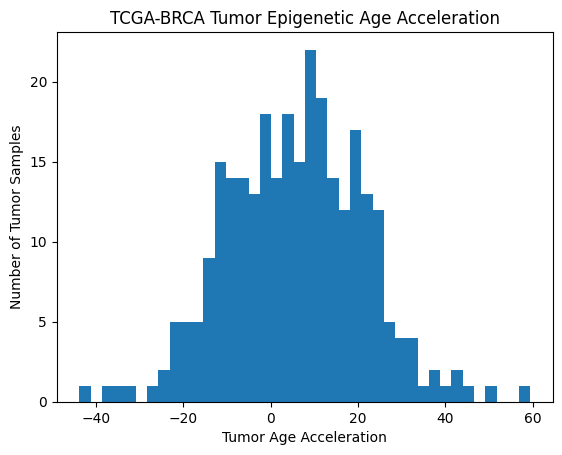

In [118]:
plt.hist(tumor_results["age_acceleration"], bins=40)
plt.xlabel("Tumor Age Acceleration")
plt.ylabel("Number of Tumor Samples")
plt.title("TCGA-BRCA Tumor Epigenetic Age Acceleration")
plt.savefig("results/plots/Tumor_epigenetic_age_acceleration_plot.png")
plt.show()

In [119]:
tumor_results.to_csv(
    "results/tables/TCGA_BRCA_tumor_epigenetic_age_results.csv",
    index=False
)

# Tumor vs Normal

## Figure 1: Actual Age vs Predicted DNAm Age

``` The clock predicts age well in normals. ```

``` The relationship is weaker in tumors. ```

In [120]:
# Normal metrics
normal_r, normal_p = pearsonr(
    normal_results["actual_age"],
    normal_results["predicted_age"]
)

normal_mae = mean_absolute_error(
    normal_results["actual_age"],
    normal_results["predicted_age"]
)

normal_r2 = r2_score(
    normal_results["actual_age"],
    normal_results["predicted_age"]
)

In [121]:
tumor_results.isna().sum()

sample_id             0
patient_id            0
actual_age            1
predicted_DNAm_age    0
age_acceleration      1
dtype: int64

In [122]:
tumor_results.dropna(inplace=True)

In [123]:
# Tumor metrics
tumor_r, tumor_p = pearsonr(
    tumor_results["actual_age"],
    tumor_results["predicted_DNAm_age"]
)

tumor_mae = mean_absolute_error(
    tumor_results["actual_age"],
    tumor_results["predicted_DNAm_age"]
)

tumor_r2 = r2_score(
    tumor_results["actual_age"],
    tumor_results["predicted_DNAm_age"]
)


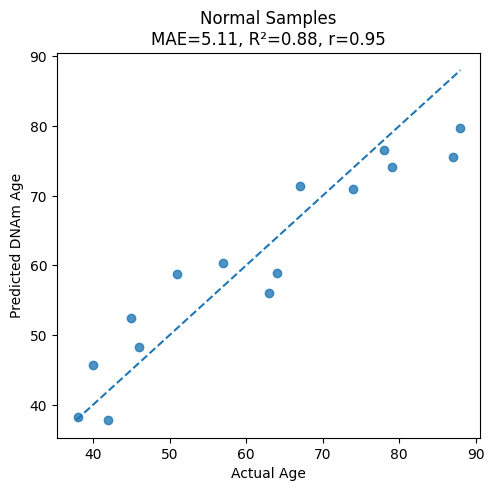

In [124]:
plt.figure(figsize=(12, 5))

# Normal
plt.subplot(1, 2, 1)
plt.scatter(
    normal_results["actual_age"],
    normal_results["predicted_age"],
    alpha=0.8
)

min_age = min(normal_results["actual_age"].min(), normal_results["predicted_age"].min())
max_age = max(normal_results["actual_age"].max(), normal_results["predicted_age"].max())

plt.plot([min_age, max_age], [min_age, max_age], linestyle="--")
plt.xlabel("Actual Age")
plt.ylabel("Predicted DNAm Age")
plt.title(
    f"Normal Samples\nMAE={normal_mae:.2f}, R²={normal_r2:.2f}, r={normal_r:.2f}"
)
plt.savefig("results/plots/Normal_Actual_vs_predicted_age.png")

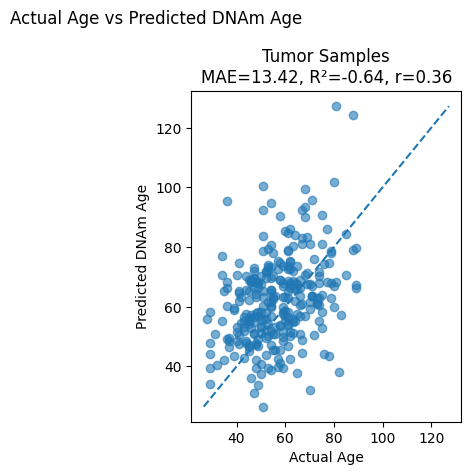

In [125]:
# Tumor
plt.subplot(1, 2, 2)
plt.scatter(
    tumor_results["actual_age"],
    tumor_results["predicted_DNAm_age"],
    alpha=0.6
)

min_age = min(tumor_results["actual_age"].min(), tumor_results["predicted_DNAm_age"].min())
max_age = max(tumor_results["actual_age"].max(), tumor_results["predicted_DNAm_age"].max())

plt.plot([min_age, max_age], [min_age, max_age], linestyle="--")
plt.xlabel("Actual Age")
plt.ylabel("Predicted DNAm Age")
plt.title(
    f"Tumor Samples\nMAE={tumor_mae:.2f}, R²={tumor_r2:.2f}, r={tumor_r:.2f}"
)

plt.suptitle("Actual Age vs Predicted DNAm Age")
plt.savefig("results/plots/Tumor_Actual_vs_predicted_age.png")
plt.tight_layout()
plt.show()

In [126]:
# plt.figure(figsize= (7,4))
# plt.hexbin(beta_normal, beta_tumor, gridsize=100, cmap = 'YlorRd')
# plt.colorbar(label='Count of CpG Probes')
# plt.title("Sample 1 vs Sample 2 Methylation Profile")
# plt.xlabel("Sample 1 Beta Value")
# plt.ylabel("Sample 2 Beta Value")
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.show()

In [127]:
tumor_results = tumor_results.dropna(subset=["age_acceleration"])

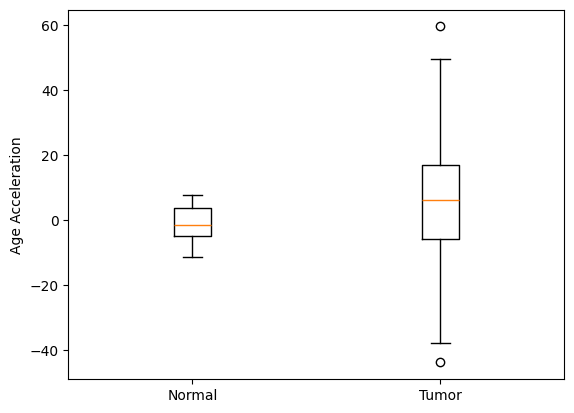

In [128]:
plt.boxplot([
    normal_results["age_acceleration"],
    tumor_results["age_acceleration"]
])

plt.xticks([1,2], ["Normal","Tumor"])
plt.ylabel("Age Acceleration")
plt.savefig("results/plots/NvsT_box_plot.png")
plt.show()

In [129]:
from scipy.stats import mannwhitneyu

stat,p = mannwhitneyu(
    normal_results["age_acceleration"],
    tumor_results["age_acceleration"]
)

print(p)

0.049795175961564964


In [130]:
normal_acc = normal_results["age_acceleration"].dropna()
tumor_acc = tumor_results["age_acceleration"].dropna()

stat, p = mannwhitneyu(
    normal_acc,
    tumor_acc,
    alternative="two-sided"
)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 1484.0
P-value: 0.049795175961564964


In [131]:
print(tumor_results["age_acceleration"].isna().sum())
print(len(tumor_results))
print(tumor_results["age_acceleration"].head())

0
283
0    15.247116
1    11.114998
2    23.862206
3     4.008560
4     8.970703
Name: age_acceleration, dtype: float64


## Figure 2. Voilen box plot

``` Distribution (violin) ```

``` Median and IQR (box) ```

``` Every individual sample (strip plot) ```

/tmp/ipykernel_11549/2679811464.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


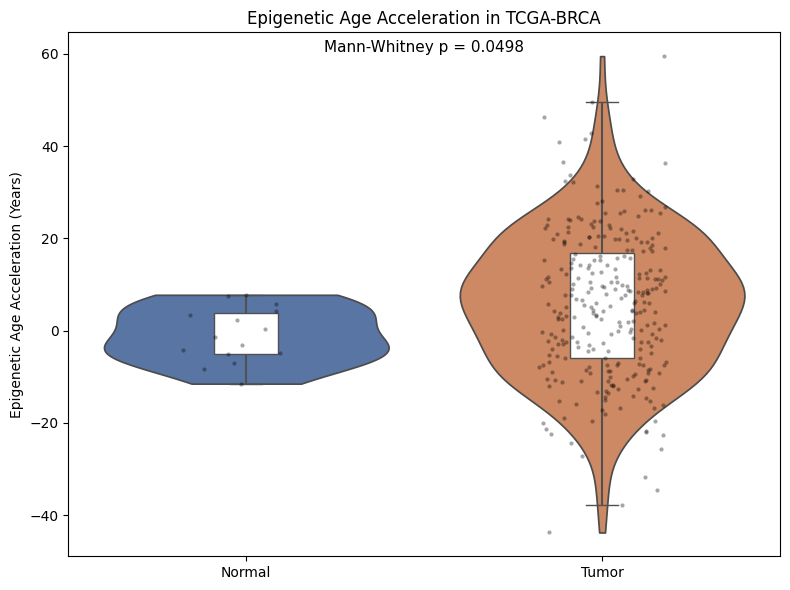

In [132]:
# Create one dataframe
plot_df = pd.DataFrame({
    "Age Acceleration": pd.concat([
        normal_results["age_acceleration"],
        tumor_results["age_acceleration"]
    ], ignore_index=True),

    "Group": (
        ["Normal"] * len(normal_results) +
        ["Tumor"] * len(tumor_results)
    )
})

plt.figure(figsize=(8,6))

# Violin
sns.violinplot(
    data=plot_df,
    x="Group",
    y="Age Acceleration",
    inner=None,
    cut=0,
    palette=["#4C72B0", "#DD8452"]
)

# Boxplot
sns.boxplot(
    data=plot_df,
    x="Group",
    y="Age Acceleration",
    width=0.18,
    showcaps=True,
    boxprops={"facecolor":"white", "zorder":3},
    showfliers=False,
    whiskerprops={"linewidth":1.5},
    medianprops={"color":"red", "linewidth":2}
)

# Individual samples
sns.stripplot(
    data=plot_df,
    x="Group",
    y="Age Acceleration",
    color="black",
    size=3,
    alpha=0.35,
    jitter=0.18
)

# Add p-value
plt.text(
    0.5,
    plot_df["Age Acceleration"].max() + 1,
    "Mann-Whitney p = 0.0498",
    ha="center",
    fontsize=11
)

plt.ylabel("Epigenetic Age Acceleration (Years)")
plt.xlabel("")
plt.title("Epigenetic Age Acceleration in TCGA-BRCA")
plt.savefig("results/plots/Epigenetic_Age_Acceleration_in_TCGA-BRCA.png")
plt.tight_layout()
plt.show()

## Figure 3. Histogram of Tumor Age Acceleration categories

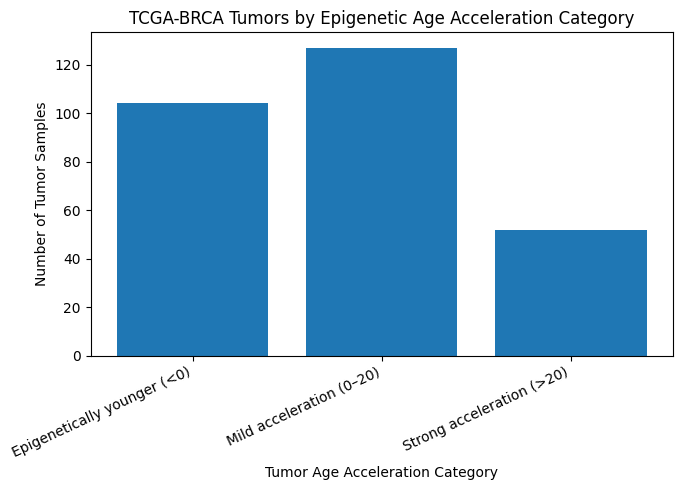

acceleration_category
Epigenetically younger (<0)    104
Mild acceleration (0–20)       127
Strong acceleration (>20)       52
Name: count, dtype: int64

In [133]:
tumor_results["acceleration_category"] = pd.cut(
    tumor_results["age_acceleration"],
    bins=[-float("inf"), 0, 20, float("inf")],
    labels=[
        "Epigenetically younger (<0)",
        "Mild acceleration (0–20)",
        "Strong acceleration (>20)"
    ]
)

category_counts = tumor_results["acceleration_category"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    category_counts.index.astype(str),
    category_counts.values
)

plt.ylabel("Number of Tumor Samples")
plt.xlabel("Tumor Age Acceleration Category")
plt.title("TCGA-BRCA Tumors by Epigenetic Age Acceleration Category")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("results/plots/Tumor_Epigenetic_Age_Acceleration_Category.png")
plt.show()

category_counts

## only clock/candidate CpG

In [134]:
# # Use only your clock CpGs
# clock_cpgs = list(X_train.columns)

# normal_pca = beta_normal[beta_normal["CpG"].isin(clock_cpgs)].drop(columns=["variance"], errors="ignore")
# tumor_pca = beta_tumor[beta_tumor["CpG"].isin(clock_cpgs)].drop(columns=["variance"], errors="ignore")

# normal_pca = normal_pca.set_index("CpG")
# tumor_pca = tumor_pca.set_index("CpG")

# # Add missing clock CpGs if any
# for cpg in clock_cpgs:
#     if cpg not in normal_pca.index:
#         normal_pca.loc[cpg] = X_train[cpg].mean()
#     if cpg not in tumor_pca.index:
#         tumor_pca.loc[cpg] = X_train[cpg].mean()

# # Reorder CpGs
# normal_pca = normal_pca.loc[clock_cpgs]
# tumor_pca = tumor_pca.loc[clock_cpgs]

# # Combine: CpGs x samples
# combined_clock = pd.concat([normal_pca, tumor_pca], axis=1)

# # Transpose: samples x CpGs
# X_pca = combined_clock.T

# metadata = pd.DataFrame({
#     "sample_id": X_pca.index,
#     "group": ["Normal" if "-11" in s else "Tumor" for s in X_pca.index]
# })

# print("PCA input shape:", X_pca.shape)

## Run PCA

In [135]:
# X_scaled = StandardScaler().fit_transform(X_pca)

# pca = PCA(n_components=2)
# pcs = pca.fit_transform(X_scaled)

# pca_df = pd.DataFrame({
#     "PC1": pcs[:, 0],
#     "PC2": pcs[:, 1],
#     "sample_id": X_pca.index
# })

# pca_df = pca_df.merge(metadata, on="sample_id", how="left")

# print("PC1 variance:", pca.explained_variance_ratio_[0])
# print("PC2 variance:", pca.explained_variance_ratio_[1])

## Plot PCA

In [136]:
# plt.figure(figsize=(7, 6))

# for group in ["Normal", "Tumor"]:
#     subset = pca_df[pca_df["group"] == group]
#     plt.scatter(subset["PC1"], subset["PC2"], label=group, alpha=0.7)

# plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
# plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
# plt.title("PCA using Clock CpGs: Normal vs Tumor")
# plt.legend()
# plt.show()